<a href="https://colab.research.google.com/github/RizkiHadiono/244107020198-Pembelajaran-Mesin/blob/main/JS04_244107020198_MOKHAMAD_RIZKI_HADIONO_SINGGIH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [2]:
import pandas as pd

df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Seleksi Fitur
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

# Menampilkan hasil seleksi fitur
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
import matplotlib.pyplot as plt

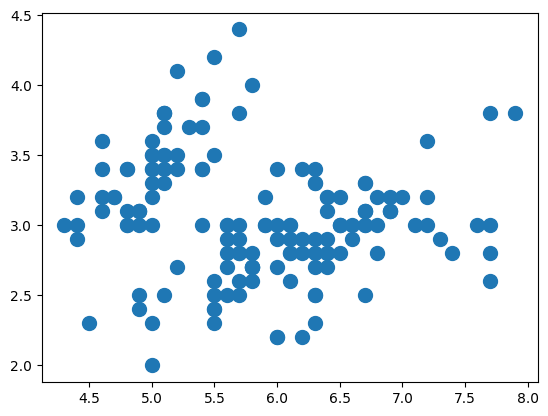

In [5]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [6]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

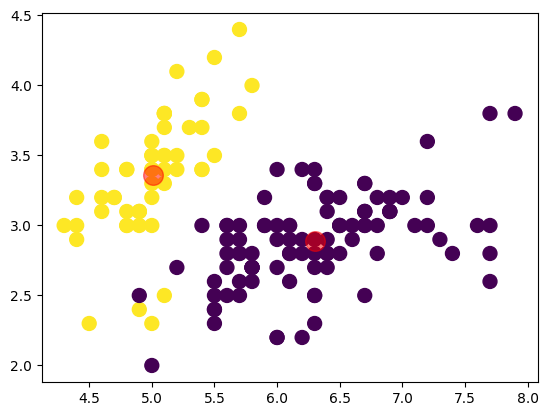

In [7]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [8]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


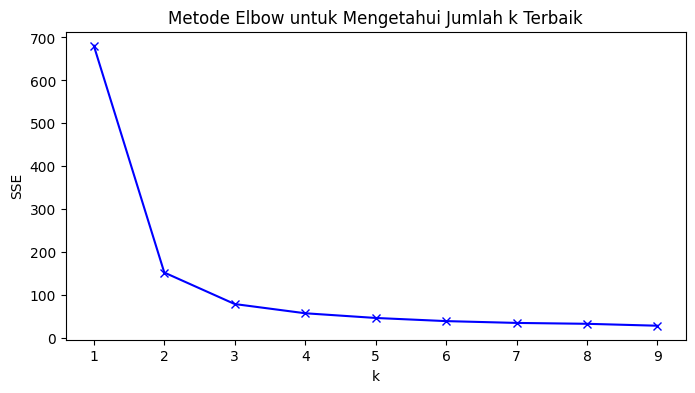

In [9]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [10]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.4732732654949
k=5; SSE=46.535582051282034
k=6; SSE=39.20485962280962
k=7; SSE=34.96859328579918
k=8; SSE=32.92113360673143
k=9; SSE=28.450679519201532


**Praktikum 2**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

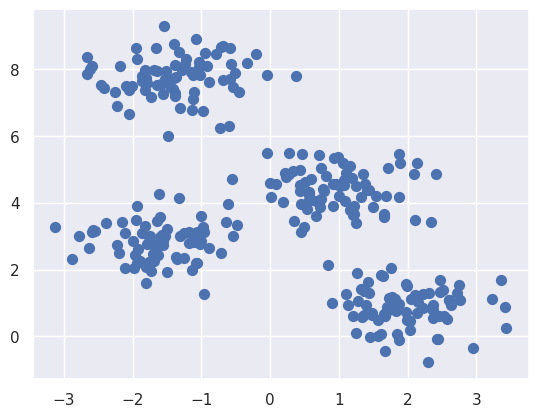

In [12]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [13]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

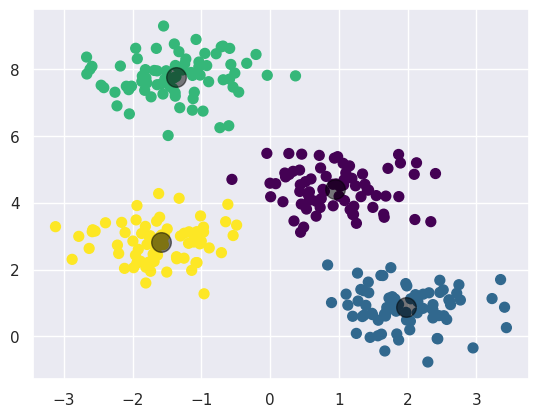

In [14]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

Algoritma Expectation-Maximization

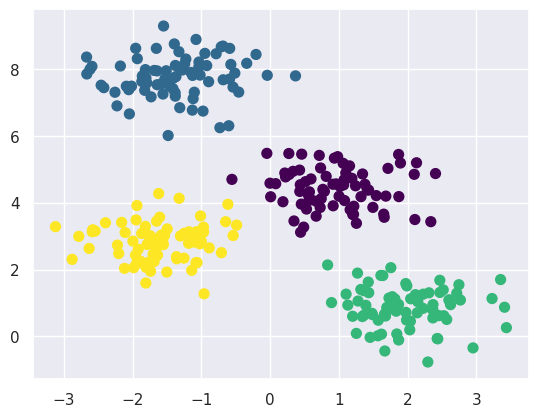

In [15]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

Perubahan random

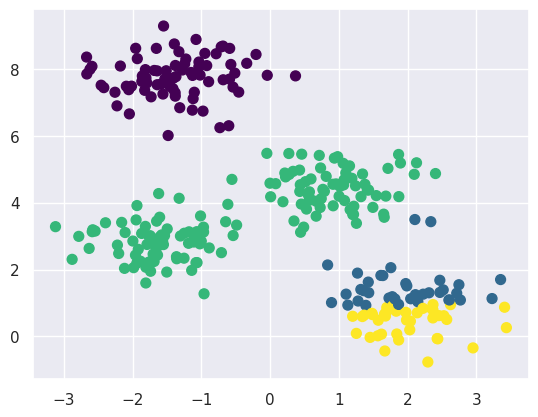

In [16]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

Optimalisasi Jumlah Klaster

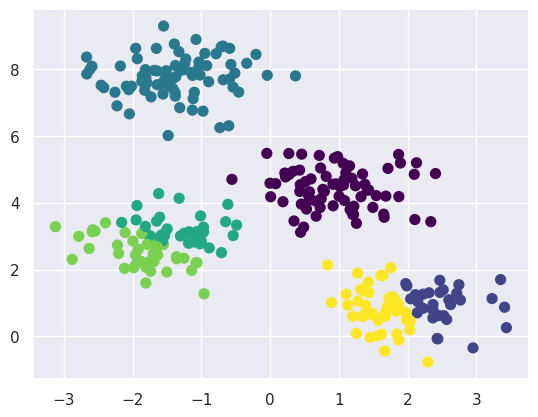

In [17]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

Batas Klaster yang Tidak Selalu Linier

In [18]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

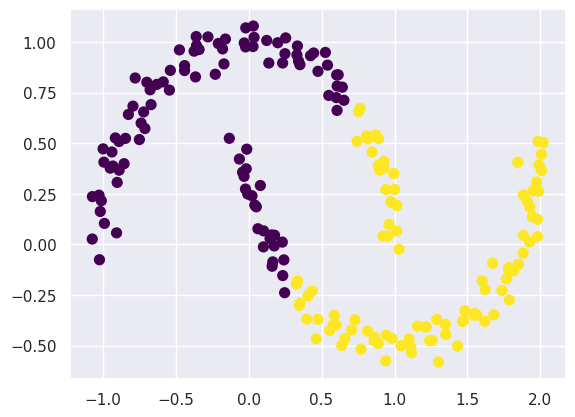

In [19]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


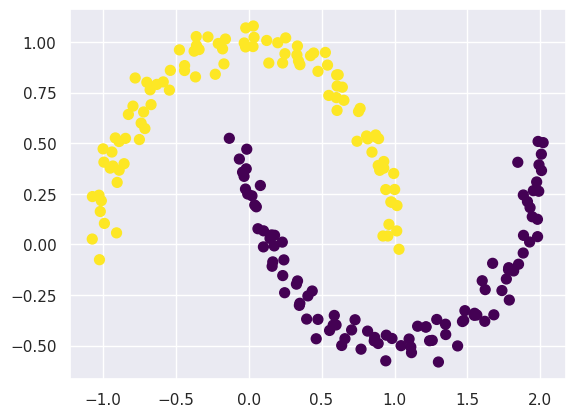

In [20]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

Contoh Kasus 1: Karakter Angka

In [21]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [22]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

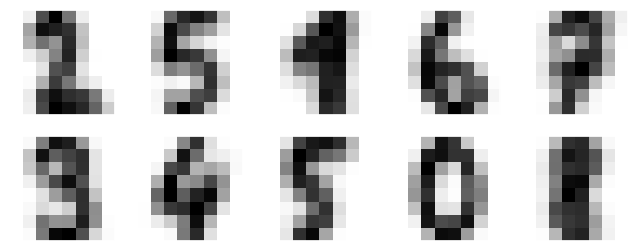

In [23]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [24]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

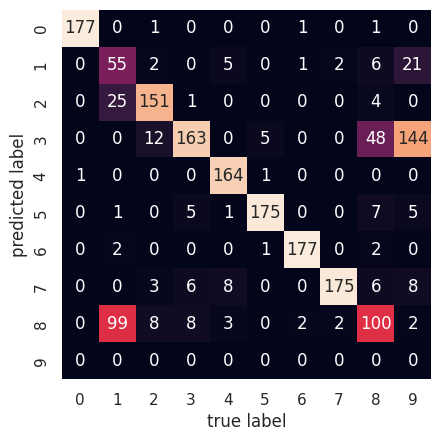

In [26]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [27]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

Studi Kasus 2: Kompresi Citra

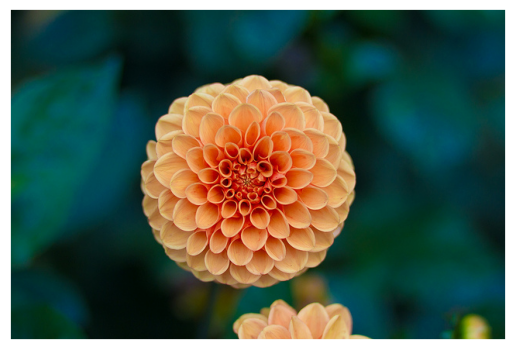

In [28]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [30]:
flower.shape

(427, 640, 3)

In [29]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [31]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

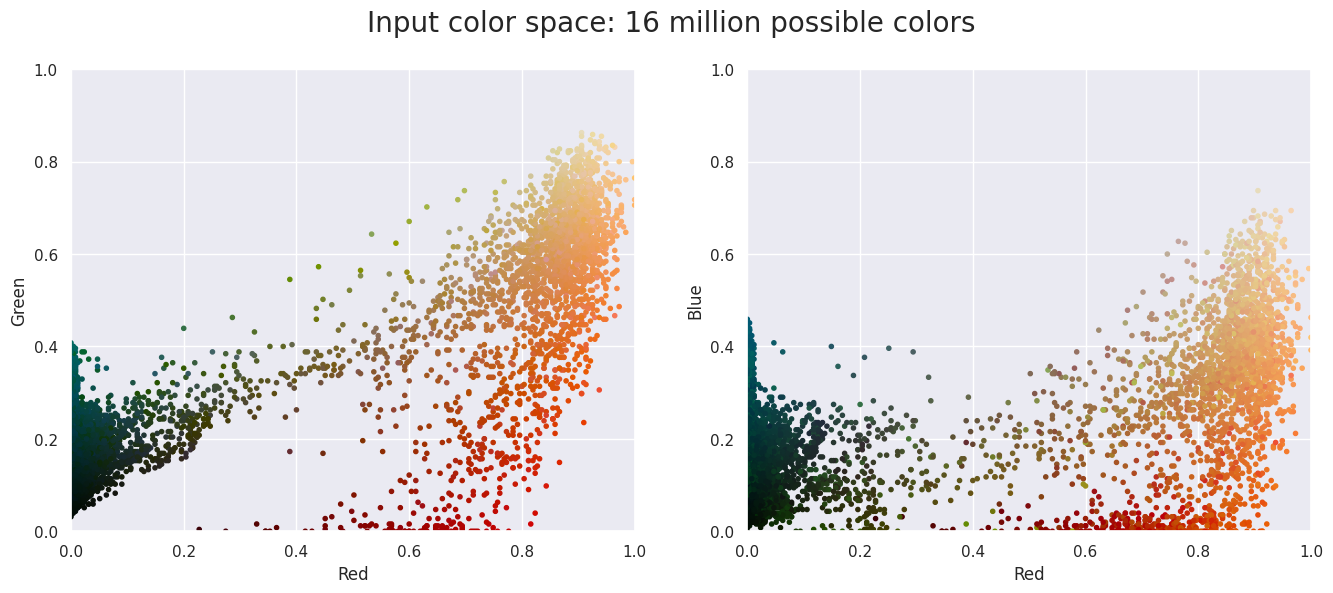

In [32]:
plot_pixels(data, title='Input color space: 16 million possible colors')

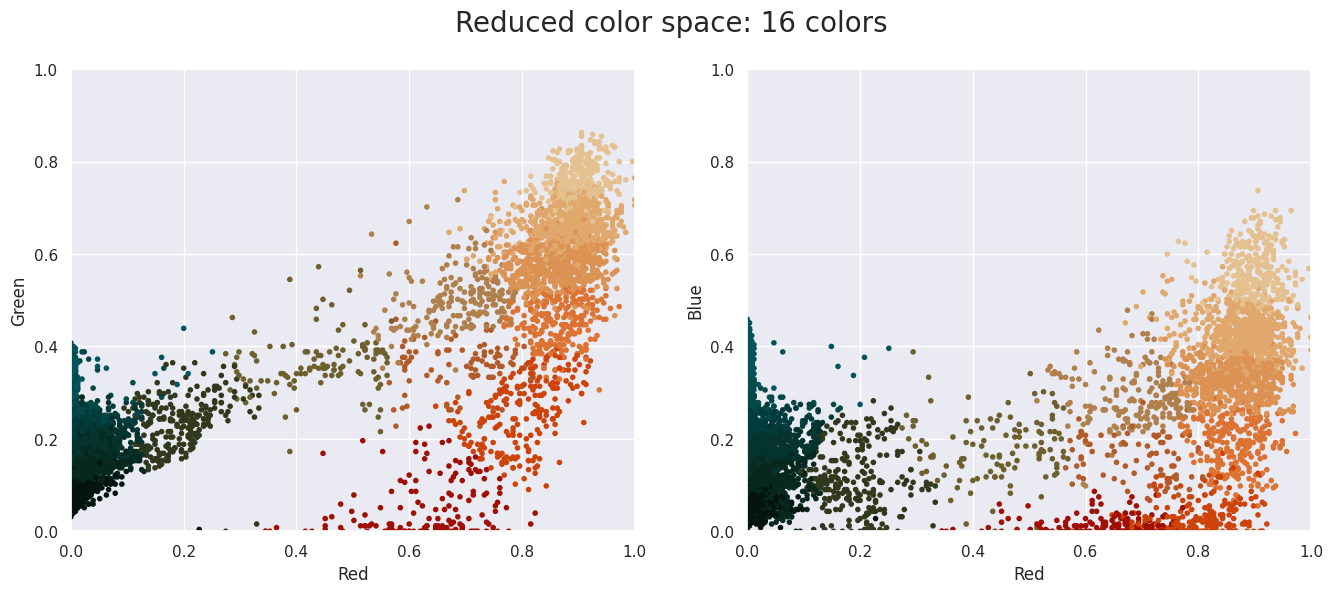

In [33]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

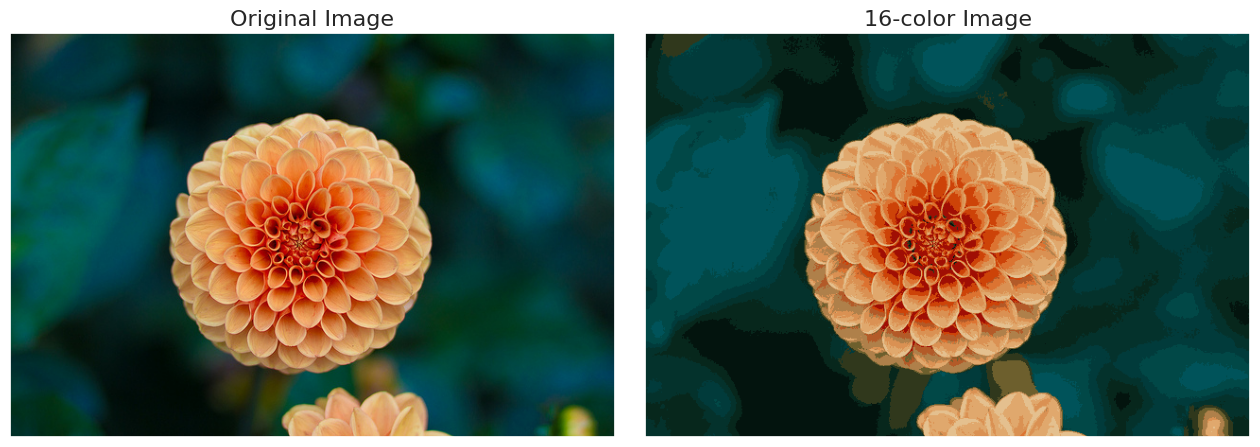

In [34]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

Praktikum 3

Pembuatan Dataset Sintetis

In [35]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]

X, labels_true = make_blobs(
    n_samples=750,
    centers=centers,
    cluster_std=0.4,
    random_state=0
)

X = StandardScaler().fit_transform(X)

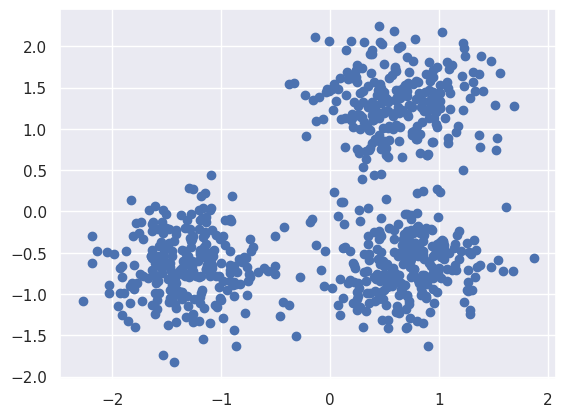

In [36]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

Compute DBSCAN

In [37]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)

labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


Evaluasi Kualitas Klasterisasi

In [38]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


Visualisasi Hasil Klasterisasi

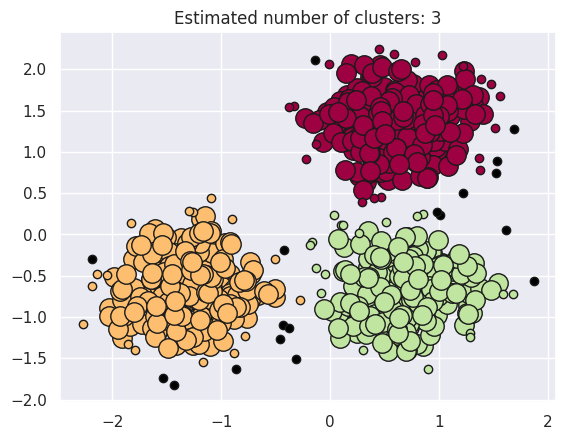

In [39]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

**Tugas Praktikum**

In [40]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [41]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


1. Tugas K-Means

=== 1. Informasi Dataset ===
Jumlah data: 200


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Informasi kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== 2. Normalisasi Data ===
Lima data pertama setelah normalisasi:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


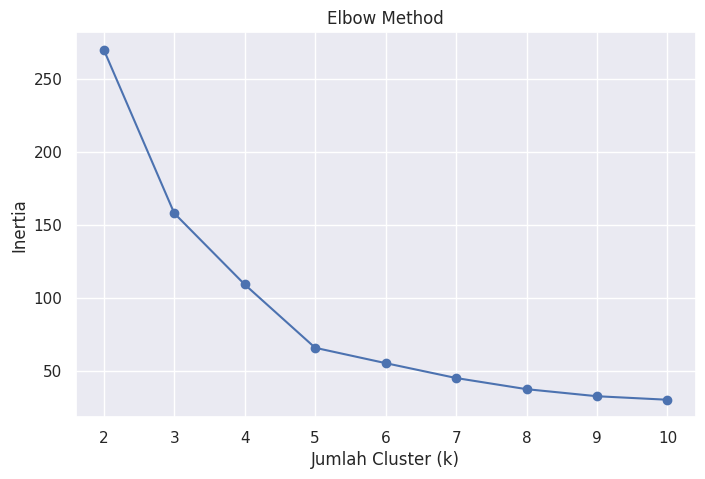


=== 3. Silhouette Score ===
k = 2, Silhouette Score = 0.3213
k = 3, Silhouette Score = 0.4666
k = 4, Silhouette Score = 0.4939
k = 5, Silhouette Score = 0.5547
k = 6, Silhouette Score = 0.5399
k = 7, Silhouette Score = 0.5281
k = 8, Silhouette Score = 0.4552
k = 9, Silhouette Score = 0.4571
k = 10, Silhouette Score = 0.4432

Jumlah cluster terpilih: 5


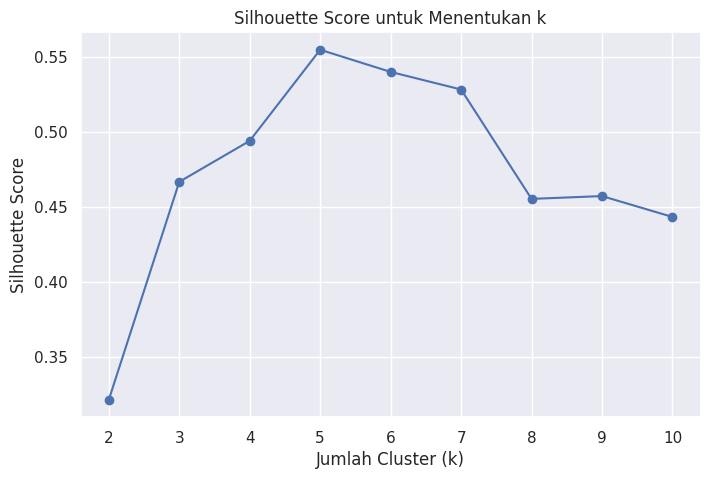


=== 4. Hasil Clustering ===


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4



=== 5. Jumlah Anggota Cluster ===


,Jumlah Pelanggan
Cluster,
0,81
1,39
2,22
3,35
4,23


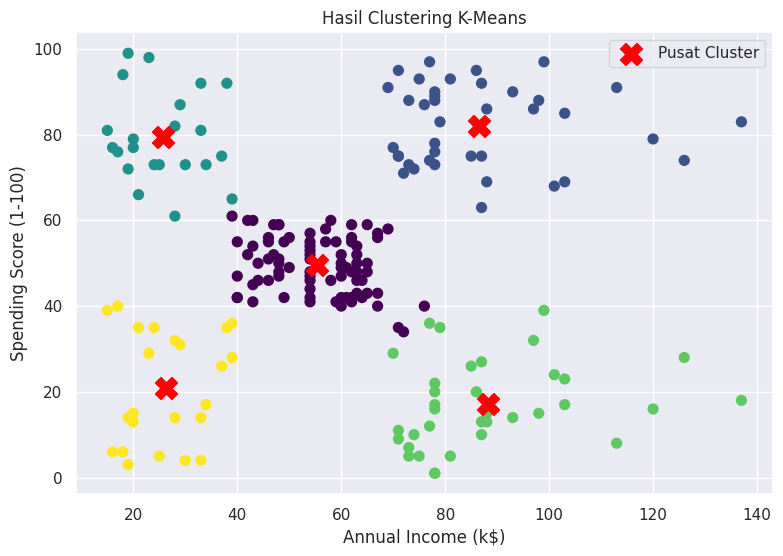


=== 6. Pusat Cluster ===


,Annual Income (k$),Spending Score (1-100)
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91



=== 7. Rata-rata Karakteristik Pelanggan per Cluster ===


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [42]:

# ==================================================
# TUGAS PRAKTIKUM JS04 - K-MEANS CLUSTERING
# Dataset: Mall_Customers.csv
# ==================================================

# LANGKAH 1: Import library
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# LANGKAH 2: Membaca dataset
df = pd.read_csv('Mall_Customers.csv')

print("=== 1. Informasi Dataset ===")
print("Jumlah data:", len(df))
display(df.head())
print("\nInformasi kolom:")
df.info()

# LANGKAH 3: Memilih fitur
# Menggunakan pendapatan tahunan dan skor pengeluaran
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# LANGKAH 4: Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== 2. Normalisasi Data ===")
print("Lima data pertama setelah normalisasi:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())

# LANGKAH 5: Elbow Method
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

# LANGKAH 6: Menghitung Silhouette Score
silhouette_scores = []

print("\n=== 3. Silhouette Score ===")

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

# Memilih k dengan Silhouette Score tertinggi
k_terbaik = range(2, 11)[
    silhouette_scores.index(max(silhouette_scores))
]

print("\nJumlah cluster terpilih:", k_terbaik)

plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Menentukan k')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

# LANGKAH 7: Membuat model K-Means
kmeans = KMeans(
    n_clusters=k_terbaik,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n=== 4. Hasil Clustering ===")
display(df.head())

# LANGKAH 8: Menghitung jumlah anggota setiap cluster
print("\n=== 5. Jumlah Anggota Cluster ===")
display(df['Cluster'].value_counts().sort_index().to_frame('Jumlah Pelanggan'))

# LANGKAH 9: Visualisasi hasil clustering
plt.figure(figsize=(9, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

# Menampilkan pusat cluster
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    marker='X',
    s=250,
    label='Pusat Cluster'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')
plt.legend()
plt.show()

# LANGKAH 10: Menampilkan karakteristik setiap cluster
centers_df = pd.DataFrame(
    centers,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

print("\n=== 6. Pusat Cluster ===")
display(centers_df.round(2))

print("\n=== 7. Rata-rata Karakteristik Pelanggan per Cluster ===")
display(
    df.groupby('Cluster')[
        ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    ].mean().round(2)
)

2. Tugas DBSCAN

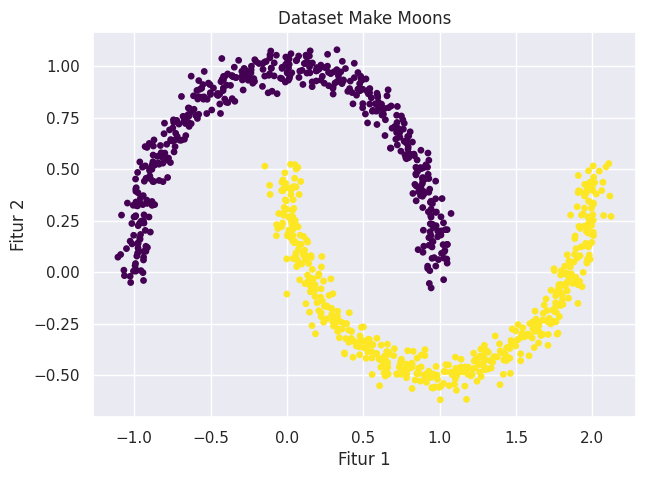

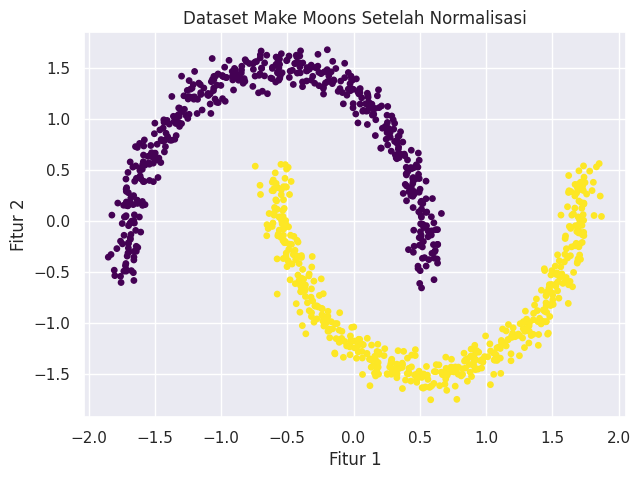

=== HASIL DBSCAN AWAL ===
eps: 0.2
min_samples: 5
Jumlah cluster: 2
Jumlah noise: 0

=== METRIK EVALUASI DBSCAN AWAL ===
Homogeneity: 1.0000
Completeness: 1.0000
V-measure: 1.0000
ARI: 1.0000
AMI: 1.0000
Silhouette: 0.3912


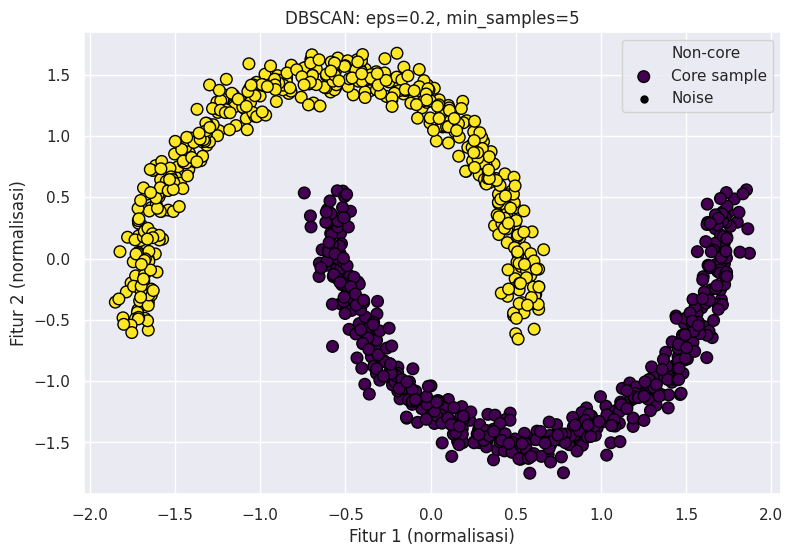


=== TABEL PERBANDINGAN EKSPERIMEN DBSCAN ===


,eps,min_samples,Jumlah Cluster,Jumlah Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.3492
1,0.05,10,3,970,0.0307,0.1268,0.0494,0.0023,0.0459,0.8807
2,0.05,20,0,1000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN
3,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.3939
4,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.2097
5,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,0.7873
6,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
7,0.30,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
8,0.30,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
9,0.50,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912



=== PERBANDINGAN BERDASARKAN ARI ===


,eps,min_samples,Jumlah Cluster,Jumlah Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.30,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
1,0.50,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
2,0.30,3,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
3,0.30,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
4,0.50,10,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
5,0.50,20,2,0,1.0000,1.0000,1.0000,1.0000,1.0000,0.3912
6,0.10,3,2,14,0.9862,0.9029,0.9427,0.9722,0.9426,0.3939
7,0.10,10,7,57,0.9433,0.4095,0.5711,0.5234,0.5698,0.2097
8,0.05,3,69,186,0.8156,0.1525,0.2570,0.0300,0.2438,0.3492
9,0.10,20,6,850,0.1539,0.1555,0.1547,0.0168,0.1509,0.7873


In [43]:

# ============================================================
# TUGAS PRAKTIKUM JS04 - DBSCAN CLUSTERING
# Dataset: make_moons (1000 sampel, noise=0.05)
# ============================================================

# LANGKAH 1: Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score
)

# LANGKAH 2: Membuat dataset make_moons
X, y = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=15, cmap='viridis')
plt.title('Dataset Make Moons')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

# LANGKAH 3: Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=y, s=15, cmap='viridis'
)
plt.title('Dataset Make Moons Setelah Normalisasi')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

# LANGKAH 4: Menjalankan DBSCAN dengan parameter awal
eps_awal = 0.2
min_samples_awal = 5

dbscan = DBSCAN(
    eps=eps_awal,
    min_samples=min_samples_awal
)

labels = dbscan.fit_predict(X_scaled)

# Menghitung jumlah cluster dan noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("=== HASIL DBSCAN AWAL ===")
print("eps:", eps_awal)
print("min_samples:", min_samples_awal)
print("Jumlah cluster:", n_clusters)
print("Jumlah noise:", n_noise)

# LANGKAH 5: Evaluasi hasil clustering
def evaluasi_dbscan(X_data, y_asli, labels_prediksi):
    # Metrik evaluasi terhadap label asli make_moons
    hasil = {
        'Homogeneity': homogeneity_score(y_asli, labels_prediksi),
        'Completeness': completeness_score(y_asli, labels_prediksi),
        'V-measure': v_measure_score(y_asli, labels_prediksi),
        'ARI': adjusted_rand_score(y_asli, labels_prediksi),
        'AMI': adjusted_mutual_info_score(y_asli, labels_prediksi)
    }

    # Silhouette dihitung jika minimal ada 2 cluster
    # pada data non-noise dan jumlah label < jumlah sampel.
    mask = labels_prediksi != -1
    labels_non_noise = labels_prediksi[mask]
    X_non_noise = X_data[mask]

    if (
        len(X_non_noise) > 1
        and 2 <= len(np.unique(labels_non_noise)) < len(X_non_noise)
    ):
        hasil['Silhouette'] = silhouette_score(
            X_non_noise,
            labels_non_noise
        )
    else:
        hasil['Silhouette'] = np.nan

    return hasil

metrik_awal = evaluasi_dbscan(X_scaled, y, labels)

print("\n=== METRIK EVALUASI DBSCAN AWAL ===")
for nama, nilai in metrik_awal.items():
    if pd.notna(nilai):
        print(f"{nama}: {nilai:.4f}")
    else:
        print(f"{nama}: Tidak dapat dihitung")

# LANGKAH 6: Visualisasi core, non-core, dan noise
core_mask = np.zeros(len(labels), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True

noise_mask = labels == -1
non_core_mask = (labels != -1) & (~core_mask)

plt.figure(figsize=(9, 6))

# Non-core: titik kecil
plt.scatter(
    X_scaled[non_core_mask, 0],
    X_scaled[non_core_mask, 1],
    c=labels[non_core_mask],
    cmap='viridis',
    s=20,
    label='Non-core'
)

# Core: titik besar
plt.scatter(
    X_scaled[core_mask, 0],
    X_scaled[core_mask, 1],
    c=labels[core_mask],
    cmap='viridis',
    s=70,
    edgecolors='black',
    label='Core sample'
)

# Noise: titik hitam
plt.scatter(
    X_scaled[noise_mask, 0],
    X_scaled[noise_mask, 1],
    c='black',
    s=25,
    label='Noise'
)

plt.title(f'DBSCAN: eps={eps_awal}, min_samples={min_samples_awal}')
plt.xlabel('Fitur 1 (normalisasi)')
plt.ylabel('Fitur 2 (normalisasi)')
plt.legend()
plt.show()

# LANGKAH 7: Eksperimen berbagai nilai eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

hasil_eksperimen = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_exp = model.fit_predict(X_scaled)

        jumlah_cluster = len(set(labels_exp)) - (
            1 if -1 in labels_exp else 0
        )
        jumlah_noise = int(np.sum(labels_exp == -1))

        metrik = evaluasi_dbscan(X_scaled, y, labels_exp)

        hasil_eksperimen.append({
            'eps': eps,
            'min_samples': min_samples,
            'Jumlah Cluster': jumlah_cluster,
            'Jumlah Noise': jumlah_noise,
            'Homogeneity': metrik['Homogeneity'],
            'Completeness': metrik['Completeness'],
            'V-measure': metrik['V-measure'],
            'ARI': metrik['ARI'],
            'AMI': metrik['AMI'],
            'Silhouette': metrik['Silhouette']
        })

# LANGKAH 8: Menampilkan tabel perbandingan eksperimen
hasil_df = pd.DataFrame(hasil_eksperimen)

print("\n=== TABEL PERBANDINGAN EKSPERIMEN DBSCAN ===")
display(hasil_df.round(4))

# LANGKAH 9: Mengurutkan hasil berdasarkan ARI
print("\n=== PERBANDINGAN BERDASARKAN ARI ===")
display(
    hasil_df.sort_values(
        by='ARI',
        ascending=False
    ).round(4).reset_index(drop=True)
)